# Assignment 4: Training a linear regression model

#### ⚠ <span style="color:red">**Please read the instructions and doc strings carefully, they are designed to help you!**</span> ⚠

## Submission Info

- Implement your solution by completing the code below
- Locations are marked with `# YOUR CODE HERE` and `raise NotImplementedError()`
- You will score points for providing a correct implementation / solution
- Exercises can be solved with given imports. Usage of standard Python libraries is allowed, but installing any additional packages or external dependencies is prohibited and will result in failing the exercise. If in doubt, don't use additional imports.
- Rename the file according to `<matriculation-number>_<assignment-number>_<filename>.ipynb` (e.g. for student with matriculation number 123456 for assignment 1 and filename intro.ipynb: `123456_1_intro.ipynb`)
- Submit the corresponding Jupyter notebook file to ILIAS


### Additional information for this assignment
- Remember to test to run your notebook top to bottom, as this is the way we will evaluate it!
- Some functions contain typing information (e.g. ``foo: list`` -> the variable ``foo`` is a ``list``). Please make sure your implementation uses the same types in function parameters and return values. For more information take a look at the at the [python typing documention](https://mypy.readthedocs.io/en/stable/).
- Some cells may be empty or only contain testing statements (see below) and are used for later evaluation. Do **not** modify or delete them.
- We provide some tests (most often ``assert`` statements) for you to check whether your implementation is correct. However, most tests are hidden, thus remember to **carefully** test the corner cases (e.g. different input parameters) of your implementation!

## Setting up the coding environment

For all coding exercises, we use Python 3. Create a virtual environment and install the libraries specified in the requirements via ```python3 -m pip install -r requirements.txt```. *Do not use any additional python packages*.
Now start the notebook and select the correct python kernel (the environment) and make sure that the imports run without error. 

---

<span style="color:red">Please also inlcude your name and matriculation number here:

## Part 1: Multivariate Linear Regression

For this exercise, we will be implementing our own linear regression models for both multivariate and complex univariate regression tasks!

#### Load Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#### Load Data

In [2]:
# Load Multivariate Data to predict housing prices.
# Columns denote Square-Footage, Number of Bedrooms and Number of Bathrooms. Y denotes the price.
train_X = np.load('data/multivariate_train_X.npy')
train_Y = np.load('data/multivariate_train_y.npy')
test_X = np.load('data/multivariate_test_X.npy')
test_Y = np.load('data/multivariate_test_y.npy')

#### Visualize Multi-Variate Data

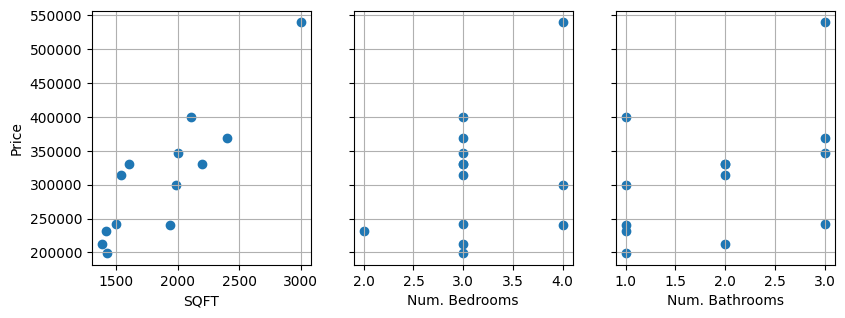

In [3]:
# We begin by visualizing each variable in isolation against the price
f, axes = plt.subplots(1, 3)
axes[0].scatter(train_X[:, 0], train_Y)
axes[1].scatter(train_X[:, 1], train_Y)
axes[2].scatter(train_X[:, 2], train_Y)
axes[0].set_xlabel('SQFT')
axes[1].set_xlabel('Num. Bedrooms')
axes[2].set_xlabel('Num. Bathrooms')
axes[0].set_ylabel('Price')
axes[1].set_yticklabels([])
axes[2].set_yticklabels([])
for ax in axes:
    ax.grid()
f.tight_layout()
f.set_size_inches(9, 3)
plt.show()

#### <span style="color:red">**[TODO]**</span> Write Multivariate Linear Regression Code (1+2+2pts)

Here, you will have to implement a function to add columns of ones to any input matrix in `offset_data()`, write a linear regressor in `regressor()`, and code up a way to use the regression weights for prediction in `predict()`. For any additional details, see each function docstring!

In [4]:
def offset_data(X: np.ndarray) -> np.ndarray:
    """Offset Input Matrix

    Task: Add a column with ones to the beginning of X.
    
    Args:
        X (np.ndarray): some input matrix

    Returns:
        np.ndarray: offset input matrix
    """
    ### BEGIN SOLUTION
    return np.concatenate([np.ones((len(X), 1)), X], axis=-1)
    ### END SOLUTION

def regressor(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Regressor function

    Task: For training data X and targets y, predict the respective weights.
    Note: Include the offset as part of this function by concatenating to X.
    
    Args:
        X (np.ndarray): [n x d] training data matrix to use.
        y (np.ndarray): [n] target values.

    Returns:
        np.ndarray: [d+1] predicted weights
    """
    ### BEGIN SOLUTION
    X = offset_data(X)
    return np.dot(np.dot(np.linalg.inv(np.dot(X.T, X)), X.T), y)
    ### END SOLUTION
    
def predict(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    """Predictor function

    Task: For test data X and weights w, predict output values.
    Note: Include the offset as part of this function by concatenating to X.
    
    Args:
        X (np.ndarray): [n x d] training data matrix to use.
        w (np.ndarray): [d+1] regressor weights.

    Returns:
        np.ndarray: [n] predicted target values
    """    
    ### BEGIN SOLUTION
    return np.dot(offset_data(X), w)
    ### END SOLUTION
    

#### Check Implementation

In [5]:
''' Check if weights are correctly computed '''
check_train_x = np.array([[1, 1.14], [0.2, 0.4]])
check_train_y = np.array([0.33, 0.11])
weights = regressor(check_train_x, check_train_y)
assert np.mean(weights) - 0.121704 < 1e-06
predictions = predict(check_train_x, weights)
assert np.mean(predictions) - 0.234146 < 1e-06
### BEGIN HIDDEN TESTS
assert weights[1] - 0.137665 < 1e-05
assert predictions[0] - 0.411312 < 1e-05
### END HIDDEN TESTS

#### Compute Fit and Predict Test Prices

In [6]:

''' Compute Weights and Predictions on Multivariate Data '''
weights = regressor(train_X, train_Y)
train_predictions = predict(train_X, weights)
test_predictions = predict(test_X, weights)
print('Predicted prices for new houses:')
for i, (feats, true_price, test_preds) in enumerate(zip(test_X, test_Y, test_predictions)):
    print(f'House {i} with {feats[0]} sqft, {feats[1]} bedrooms and {feats[2]} bathrooms. Sold for {true_price}$. Predicted Price: {test_preds:6.2f}$')
### BEGIN HIDDEN TESTS
assert np.mean(weights) - 4121.43239 < 1e-05
assert np.mean(test_predictions) - 264703.6447765 < 1e-05
### END HIDDEN TESTS

Predicted prices for new houses:
House 0 with 1600 sqft, 3 bedrooms and 1 bathrooms. Sold for 329900$. Predicted Price: 254473.54$
House 1 with 1890 sqft, 4 bedrooms and 2 bathrooms. Sold for 369000$. Predicted Price: 293224.05$
House 2 with 2180 sqft, 4 bedrooms and 2 bathrooms. Sold for 314900$. Predicted Price: 345341.73$
House 3 with 1000 sqft, 2 bedrooms and 1 bathrooms. Sold for 198999$. Predicted Price: 171333.01$
House 4 with 1500 sqft, 3 bedrooms and 3 bathrooms. Sold for 239999$. Predicted Price: 259145.90$


#### <span style='color: red'>**[TODO]**</span> Implement R^2 Score (2pts)

Here, we will implement the R^2 Score to evaluate the quality of our regression fit! For details on the respective input or output, check the docstring.

In [7]:
def compute_r2_score(preds: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Compute R2
    
    Task: Compute R2-score.
    
    Args:
        preds (np.ndarray): [n] predictions
        y (np.ndarray): [n] targets

    Returns:
        float: np.ndarray
    """
    ### BEGIN SOLUTION
    return 1 - np.sum((y - preds)**2) / np.sum((y - np.mean(y))**2)
    ### END SOLUTION

#### Compute R^2 Score

In [8]:
''' Test your R^2 Score '''
preds = np.array([1.1, 2.3, 1.4])
r = np.array([1.05, 2.11, 1.62])
r2_score = compute_r2_score(preds, r)
assert abs(r2_score - 0.845434087) < 1e-06

In [9]:
''' Compute R^2 of multivariate fit '''
r2_score = compute_r2_score(train_predictions, train_Y)
print(f'The computed multivariate linear regression has a R^2 value of {r2_score:0.3f}!')
### BEGIN HIDDEN TESTS
r2_score_test = compute_r2_score(test_predictions, test_Y)
assert abs(r2_score_test - 0.298599197) < 1e-05
### END HIDDEN TESTS

The computed multivariate linear regression has a R^2 value of 0.803!


---

## Part 2: Complex Univariate Linear Regression

In this part, we extend our previous implementions and test them for regression on complicated univariate data.

In [10]:
''' Load new univariate data '''
x = np.linspace(0, 10, 40).reshape(-1, 1)
simple_y = np.load('data/univariate_easy_y_0.npy')
hard_y = np.load('data/univariate_hard_y_0.npy')

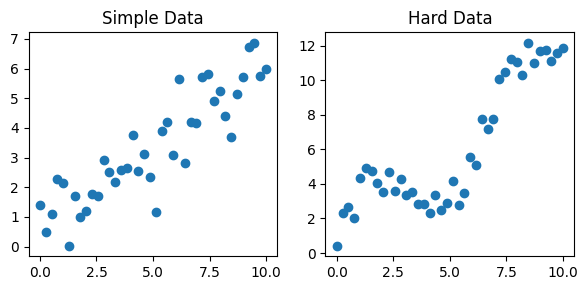

In [11]:
''' Visualize Simple and Hard Data '''
f, ax = plt.subplots(1, 2)
ax[0].scatter(x, simple_y)
ax[0].set_title('Simple Data')
ax[1].scatter(x, hard_y)
ax[1].set_title('Hard Data')
f.set_size_inches(6, 3)
f.tight_layout()
plt.show()

#### <span style='color: red'>**[TODO]**</span> Fit a simple linear regressor to linear data (1pt)

Here, we will write a regression function for simply univariate linear regression. If you implemented the `regressor()` function from above correctly and generic enough, you can simply re-use it here.

In [12]:
''' Fitting to simple univariate data - restructure so we can re-use previous function. '''
def simple_regressor(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Simple Regressor function

    Task: For training data X and targets y, predict the respective weights. 
    IMPORTANT:  If you did everything correctly, you should be able to use your previous regressor() function.
                This will be very useful for the upcoming task as well!
    
    Args:
        X (np.ndarray): [n x 1] training data vector to use.
        y (np.ndarray): [n] target values.

    Returns:
        np.ndarray: [n=2] predicted weights
    """    
    ### BEGIN SOLUTION
    return regressor(x, y)
    ### END SOLUTION

In [13]:
''' Test Simple Regressor '''
weights = simple_regressor(x, simple_y)
predictions = predict(x, weights)
assert np.mean(weights) - 0.5918496588 < 1e-06
assert np.mean(predictions) - 3.3670339785 < 1e-06
### BEGIN HIDDEN TESTS
simple_y2 = np.load('data/univariate_easy_y_1.npy')
weights_y2 = simple_regressor(x, simple_y2)
predictions_y2 = predict(x, weights_y2)
assert np.mean(weights_y2) - 0.103968467 < 1e-06
assert np.mean(predictions_y2) - 2.818098366 < 1e-06
### END HIDDEN TESTS

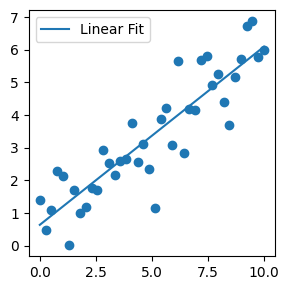

In [14]:
''' Visualize Fit '''
f, ax = plt.subplots(1)
ax.scatter(x, simple_y)
ax.plot(x, predictions, label='Linear Fit')
ax.legend()
f.set_size_inches(3, 3)
f.tight_layout()
plt.show()

#### <span style='color: red'>**[TODO]**</span> Fit a linear regressor to complex data (2pts)

Finally, we will utilize our `regressor()` function to produce a fit over much more complex univariate data without a linear relation. For that, we need to prepare a correct set of input features `X` that we can pass to our regressor. To do so, simply adapt `produce_basis_functions()`.

In [15]:
def produce_basis_functions(x: np.ndarray) -> np.ndarray:
    """Feature generation

    Task: For training data x, we want to generate features to add polynomial and trigonometric context into our regression.
    Use x [dim=n] to produce a matrix X [dim=n x d] where each column encodes basis functions for polynomials from degree 1 to 5, as well as cosine, sine and tangent.
    
    IMPORTANT: Make sure that you follow the ordering of [polynomial_1 (i.e. x), ..., polynomial_5 (i.e. x^5), cosine, sine, tangent].
    
    Args:
        x (np.ndarray): [n] training data to convert.

    Returns:
        np.ndarray: [n x d] produced feature matrix with 
    """
    if len(x.shape) > 1: x = x.reshape(-1)
    ### BEGIN SOLUTION
    return np.array([
        x,
        x**2,
        x**3,
        x**4,
        x**5,
        np.cos(x),
        np.sin(x),
        np.tan(x)
    ]).T           
    ### END SOLUTION

In [16]:
''' Featurize independent variable x '''
featurized_x = produce_basis_functions(x)
assert featurized_x.shape == (40, 8)
assert np.mean(featurized_x[:, 6]) - 0.171525722 < 1e-06
### BEGIN HIDDEN TESTS
assert np.mean(featurized_x) - 2487.485242615564 < 1e-06
### END HIDDEN TESTS

In [17]:
''' Fitting to complex univariate data - restructure so we can re-use previous function. '''
weights = regressor(featurized_x, hard_y)
predictions = predict(featurized_x, weights)
assert weights[6] + 2.15535024259 < 1e-06
assert predictions[6] - 4.858068 < 1e-05
### BEGIN HIDDEN TESTS
assert np.mean(weights) - 0.328146196 < 1e-06
assert np.mean(predictions) - 6.07737767266 < 1e-06
### END HIDDEN TESTS

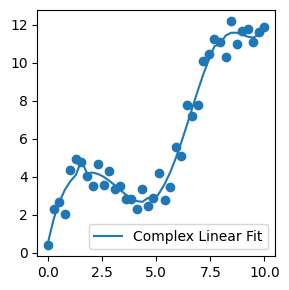

In [18]:
''' Visualize Complex Fit '''
f, ax = plt.subplots(1)
ax.scatter(x, hard_y)
ax.plot(x, predictions, label='Complex Linear Fit')
ax.legend()
f.set_size_inches(3, 3)
f.tight_layout()
plt.show()

# END OF EXERCISE